In [ ]:
!pip install -q huggingface_hub datasets transformers sentence-transformers scikit-learn

import os
from huggingface_hub import login

HF_TOKEN = "add your hugging face token here"

os.environ["HF_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# RQ1 — BART Summarization of Climate Policy Documents

##Can a summarization model generate useful summaries of climate policy documents?


torchvision is installed. Removing it because it is not needed for text summarization...
Installing / updating required packages. This may take a few minutes...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF_TOKEN found in environment.
Listing dataset files from Hugging Face: ClimatePolicyRadar/all-document-text-data
Found 48 Parquet file(s).
First file: datasets/ClimatePolicyRadar/all-document-text-data/train_0.parquet

Reading Parquet file in small batches:
datasets/ClimatePolicyRadar/all-document-text-data/train_0.parquet

Total rows scanned: 20000
Usable text rows: 19964
Document IDs collected: 11
Reconstructed usable documents: 11


,doc_id,title,country,year,word_count
0,AF.document.002MMUCR.n0004,Final evaluation report,MUS,2011,43622
1,AF.document.004MSBFR.n0007,Final evaluation report,SLB,2011,43465
2,AF.document.002MMUCR.n0002,Mid-term evaluation report,MUS,2011,41952
3,AF.document.005MNIWR.n0001,Inception report,NIC,2010,38524
4,AF.document.003MTMWR.n0002,Mid-term evaluation report,TKM,2011,35175


Using device: cpu

Loading summarization model: facebook/bart-large-cnn


...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Model loaded successfully: facebook/bart-large-cnn

Running summarization for 10 documents...
Summarizing document 1/10
Summarizing document 2/10
Summarizing document 3/10
Summarizing document 4/10
Summarizing document 5/10
Summarizing document 6/10
Summarizing document 7/10
Summarizing document 8/10
Summarizing document 9/10
Summarizing document 10/10

Saved CSV table to: outputs/tables_csv/rq1_bart_summary_results.csv


,doc_id,title,country,year,model_used,original_words_used,summary_words,compression_ratio,theme_coverage,generated_summary
0,AF.document.002MMUCR.n0004,Final evaluation report,MUS,2011,facebook/bart-large-cnn,566,52,0.091873,1.000000,April Final Report 1 2020 Terminal Evaluation ...
1,AF.document.004MSBFR.n0007,Final evaluation report,SLB,2011,facebook/bart-large-cnn,534,26,0.048689,0.666667,Terminal Evaluation Report Strongem Waka lo Co...
2,AF.document.002MMUCR.n0002,Mid-term evaluation report,MUS,2011,facebook/bart-large-cnn,589,39,0.066214,0.500000,"Revised January 26, 2015 Mid - Term Evaluation..."
3,AF.document.005MNIWR.n0001,Inception report,NIC,2010,facebook/bart-large-cnn,551,49,0.088929,1.000000,Workshop to launch the Flood and Drought Risk ...
4,AF.document.003MTMWR.n0002,Mid-term evaluation report,TKM,2011,facebook/bart-large-cnn,538,47,0.087361,0.333333,Addressing climate change risks to farming sys...


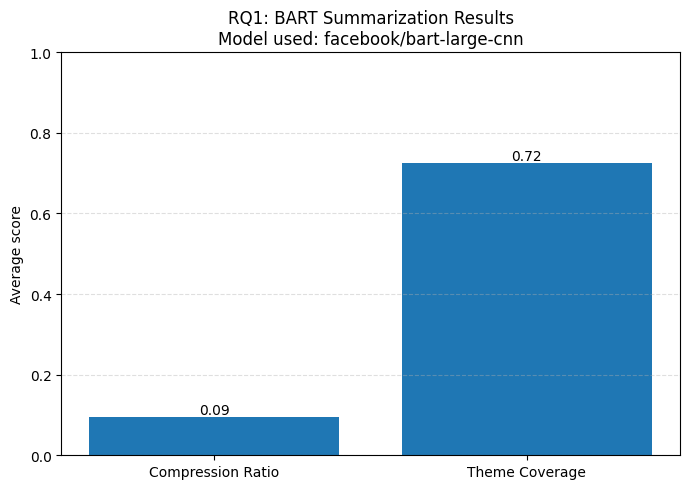

Saved PDF figure to: outputs/figures_pdf/rq1_bart_summary_results.pdf

DONE. Your outputs are ready:
1. Table:  outputs/tables_csv/rq1_bart_summary_results.csv
2. Figure: outputs/figures_pdf/rq1_bart_summary_results.pdf

Your current working folder is:
/content

Open this folder in VS Code / Windows Explorer, then open the 'outputs' folder.


In [2]:

# ============================================================
# RQ1 ONE-CLICK RUNNABLE VERIFIED FULL FIX
# BART Summarization of Climate Policy Documents
# ============================================================
#
# Run this whole cell once.
# It creates:
#   outputs/tables_csv/rq1_bart_summary_results.csv
#   outputs/figures_pdf/rq1_bart_summary_results.pdf
#
# This notebook is designed to run in VS Code, Colab, or Kaggle.

# ------------------------------------------------------------
# STEP 0 — Environment preparation
# ------------------------------------------------------------
# Why this step exists:
# Your earlier error came from a broken torchvision installation that interfered
# with importing BART from transformers. This notebook removes torchvision because
# it is not needed for text summarization.

import os
import sys
import re
import json
import getpass
import subprocess
import importlib.util
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Avoid optional vision backends where possible.
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"


def run_pip(args):
    """Run pip quietly and keep output readable."""
    cmd = [sys.executable, "-m", "pip"] + args
    subprocess.run(cmd, check=False)


def uninstall_broken_torchvision():
    """
    Remove torchvision if it is installed.

    Beginner explanation:
    We do not need torchvision because this project is text-only.
    Your error 'operator torchvision::nms does not exist' comes from a mismatch
    between torch and torchvision. Removing torchvision prevents transformers
    from trying to load broken vision code.
    """
    try:
        import torchvision  # noqa: F401
        print("torchvision is installed. Removing it because it is not needed for text summarization...")
        run_pip(["uninstall", "-y", "torchvision"])
    except Exception:
        print("torchvision is absent or broken. Ensuring it is removed...")
        run_pip(["uninstall", "-y", "torchvision"])

    # Clear partially imported modules from memory.
    for name in list(sys.modules.keys()):
        if name.startswith("torchvision"):
            del sys.modules[name]


uninstall_broken_torchvision()

# ------------------------------------------------------------
# STEP 1 — Install required packages
# ------------------------------------------------------------
# Why this step exists:
# We pin transformers to a stable version for text generation/summarization.
# This avoids the torchvision-related import issue seen in newer environments.

print("Installing / updating required packages. This may take a few minutes...")

run_pip([
    "install", "-q", "-U",
    "huggingface_hub",
    "fsspec",
    "pyarrow",
    "pandas",
    "matplotlib",
    "sentencepiece",
    "accelerate",
    "torch",
    "transformers==4.44.2"
])

# Clear transformers from memory if an old version was already imported.
for name in list(sys.modules.keys()):
    if name.startswith("transformers"):
        del sys.modules[name]

# ------------------------------------------------------------
# STEP 2 — Imports after environment fix
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyarrow.parquet as pq

from huggingface_hub import HfFileSystem, login
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ------------------------------------------------------------
# STEP 3 — Notebook settings
# ------------------------------------------------------------

DATASET_ID = "ClimatePolicyRadar/all-document-text-data"
PRIMARY_MODEL_NAME = "facebook/bart-large-cnn"
FALLBACK_MODEL_NAME = "sshleifer/distilbart-cnn-12-6"

# Keep this small for one-click laptop/Colab runs.
# Increase later if you want stronger final results.
N_DOCS_TO_SUMMARIZE = 10
TARGET_RECONSTRUCTED_DOCS = 50
PARQUET_BATCH_SIZE = 128
MAX_ROWS = 20000
MIN_DOC_WORDS = 120
MAX_INPUT_WORDS = 650

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
TABLE_DIR = OUTPUT_DIR / "tables_csv"
FIGURE_DIR = OUTPUT_DIR / "figures_pdf"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# STEP 4 — Hugging Face token setup
# ------------------------------------------------------------

def setup_hf_token():
    """
    Get Hugging Face token.

    Important:
    The Climate Policy Radar dataset is public but gated.
    You must first open the dataset page in a browser and click to accept access:
    https://huggingface.co/datasets/ClimatePolicyRadar/all-document-text-data
    """
    token = os.environ.get("HF_TOKEN", "").strip()

    if token:
        print("HF_TOKEN found in environment.")
        try:
            login(token=token, add_to_git_credential=False)
        except Exception as e:
            print("Hugging Face login warning:", e)
        return token

    print("HF_TOKEN not found.")
    print("Paste your Hugging Face token. It starts with hf_")
    token = getpass.getpass("HF_TOKEN: ").strip()

    if not token:
        raise ValueError("No Hugging Face token was entered.")

    os.environ["HF_TOKEN"] = token

    try:
        login(token=token, add_to_git_credential=False)
    except Exception as e:
        print("Hugging Face login warning:", e)

    return token

HF_TOKEN = setup_hf_token()

# ------------------------------------------------------------
# STEP 5 — Helper functions
# ------------------------------------------------------------

def safe_to_str(x):
    """Convert any value into a readable string."""
    if x is None:
        return ""
    if isinstance(x, (list, tuple, set)):
        return "; ".join(safe_to_str(i) for i in x)
    if isinstance(x, dict):
        return json.dumps(x, ensure_ascii=False)
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x)


def clean_text(text):
    """Remove repeated spaces and line breaks."""
    text = safe_to_str(text)
    return re.sub(r"\s+", " ", text).strip()


def first_n_words(text, n):
    """Keep only the first n words."""
    words = re.findall(r"\b\w+\b|[^\w\s]", clean_text(text))
    return " ".join(words[:n])


def word_count(text):
    """Count words in a text."""
    return len(re.findall(r"\b\w+\b", clean_text(text)))


def extract_year(value):
    """Extract a publication year from metadata."""
    s = safe_to_str(value)
    m = re.search(r"(19[5-9]\d|20[0-4]\d)", s)
    return int(m.group(1)) if m else np.nan


def normalize_country(value):
    """Extract a readable country/geography string."""
    if value is None:
        return "Unknown"

    if isinstance(value, list) and len(value) > 0:
        first = value[0]
        if isinstance(first, dict):
            for k in ["display_value", "value", "name", "slug"]:
                if first.get(k):
                    return safe_to_str(first[k])
            return safe_to_str(first)
        return safe_to_str(first)

    if isinstance(value, dict):
        for k in ["display_value", "value", "name", "slug"]:
            if value.get(k):
                return safe_to_str(value[k])
        return safe_to_str(value)

    s = safe_to_str(value).strip()
    if not s:
        return "Unknown"
    s = re.sub(r"[\[\]\{\}\"']", "", s)
    for sep in [";", "|", ","]:
        if sep in s:
            s = s.split(sep)[0].strip()
            break
    return s if s else "Unknown"


def get_value(obj, path, default=None):
    """
    Read flat or nested values from a row.

    Examples supported:
    - row['text_block.text']
    - row['text_block']['text']
    """
    if obj is None:
        return default

    if isinstance(obj, dict) and path in obj:
        return obj[path]

    cur = obj
    for part in path.split("."):
        if isinstance(cur, dict) and part in cur:
            cur = cur[part]
        else:
            return default
    return cur


THEME_KEYWORDS = {
    "Energy": ["energy", "renewable", "solar", "wind", "electricity", "power", "grid", "hydrogen"],
    "Transport": ["transport", "vehicle", "mobility", "rail", "aviation", "shipping", "public transport", "electric vehicle"],
    "Adaptation": ["adaptation", "resilience", "disaster", "flood", "drought", "risk", "vulnerability", "climate-resilient"],
    "Emissions Reduction": ["emission", "emissions", "carbon", "greenhouse gas", "ghg", "net zero", "decarbonization", "mitigation"],
    "Climate Finance": ["finance", "funding", "investment", "budget", "grant", "loan", "climate finance", "fund"],
    "Agriculture": ["agriculture", "farmer", "crop", "livestock", "soil", "food security", "forestry", "land use"],
}


def keyword_count(text, keywords):
    """Count theme keywords in text."""
    text_l = clean_text(text).lower()
    total = 0
    for kw in keywords:
        total += len(re.findall(r"\b" + re.escape(kw.lower()) + r"\b", text_l))
    return total


def theme_coverage(full_text, summary_text):
    """
    Measure how many climate themes from the input are preserved in the summary.
    """
    full_themes = {theme for theme, kws in THEME_KEYWORDS.items() if keyword_count(full_text, kws) > 0}
    summary_themes = {theme for theme, kws in THEME_KEYWORDS.items() if keyword_count(summary_text, kws) > 0}

    if not full_themes:
        return np.nan

    return len(full_themes.intersection(summary_themes)) / len(full_themes)

# ------------------------------------------------------------
# STEP 6 — Low-memory Climate Policy Radar dataset loader
# ------------------------------------------------------------

def list_cpr_parquet_files():
    """
    List Parquet files in the gated Hugging Face dataset repository.

    This avoids Hugging Face datasets streaming, which caused ArrowMemoryError.
    """
    print(f"Listing dataset files from Hugging Face: {DATASET_ID}")
    fs = HfFileSystem(token=HF_TOKEN)
    files = fs.glob(f"datasets/{DATASET_ID}/**/*.parquet")

    if not files:
        raise FileNotFoundError(
            "No Parquet files found. Check that you accepted dataset access and your token has gated repo access."
        )

    print(f"Found {len(files)} Parquet file(s).")
    print("First file:", files[0])
    return fs, files


def extract_row_fields(row):
    """Extract the fields needed from one Climate Policy Radar row."""
    doc_id = safe_to_str(get_value(row, "document_id", ""))
    if not doc_id:
        doc_id = safe_to_str(get_value(row, "document_import_id", ""))

    text = get_value(row, "text_block.text", "")
    if not text:
        text = get_value(row, "text", "")
    text = clean_text(text)

    block_index = get_value(row, "text_block.index", 0)
    try:
        block_index = int(block_index)
    except Exception:
        block_index = 0

    title = safe_to_str(get_value(row, "document_metadata.document_title", ""))
    country = normalize_country(get_value(row, "document_metadata.geographies", None))
    year = extract_year(get_value(row, "document_metadata.publication_ts", ""))

    return {
        "doc_id": doc_id,
        "text": text,
        "block_index": block_index,
        "title": title,
        "country": country,
        "year": year,
    }


def load_cpr_documents_low_memory():
    """
    Load and reconstruct documents using low memory.

    How it works:
    - opens one Parquet file at a time from Hugging Face,
    - reads small batches,
    - groups text blocks by document_id,
    - stops after collecting enough documents.
    """
    fs, parquet_files = list_cpr_parquet_files()

    docs = {}
    total_rows = 0
    usable_rows = 0

    for parquet_path in parquet_files:
        print("\nReading Parquet file in small batches:")
        print(parquet_path)

        with fs.open(parquet_path, "rb") as f:
            pf = pq.ParquetFile(f)
            schema_names = set(pf.schema_arrow.names)

            candidate_columns = [
                "document_id",
                "document_import_id",
                "text_block",
                "text_block.text",
                "text_block.index",
                "document_metadata",
                "document_metadata.document_title",
                "document_metadata.geographies",
                "document_metadata.publication_ts",
                "text",
            ]
            columns = [c for c in candidate_columns if c in schema_names]
            if not columns:
                columns = None

            batch_iter = pf.iter_batches(batch_size=PARQUET_BATCH_SIZE, columns=columns)

            for batch in batch_iter:
                table = batch.to_pydict()
                keys = list(table.keys())
                if not keys:
                    continue

                batch_len = len(next(iter(table.values())))

                for i in range(batch_len):
                    if total_rows >= MAX_ROWS:
                        break

                    total_rows += 1
                    row = {k: table[k][i] for k in keys}
                    fields = extract_row_fields(row)

                    if not fields["text"]:
                        continue

                    usable_rows += 1
                    doc_id = fields["doc_id"] if fields["doc_id"] else f"row_{total_rows}"

                    if doc_id not in docs:
                        docs[doc_id] = {
                            "doc_id": doc_id,
                            "title": fields["title"],
                            "country": fields["country"],
                            "year": fields["year"],
                            "parts": []
                        }

                    docs[doc_id]["parts"].append((fields["block_index"], fields["text"]))

                if len(docs) >= TARGET_RECONSTRUCTED_DOCS or total_rows >= MAX_ROWS:
                    break

        if len(docs) >= TARGET_RECONSTRUCTED_DOCS or total_rows >= MAX_ROWS:
            break

    print(f"\nTotal rows scanned: {total_rows}")
    print(f"Usable text rows: {usable_rows}")
    print(f"Document IDs collected: {len(docs)}")

    records = []
    for doc_id, d in docs.items():
        parts_sorted = sorted(d["parts"], key=lambda x: x[0])
        full_text = clean_text(" ".join(part for _, part in parts_sorted))
        wc = word_count(full_text)

        if wc < MIN_DOC_WORDS:
            continue

        records.append({
            "doc_id": d["doc_id"],
            "title": d["title"],
            "country": d["country"],
            "year": d["year"],
            "full_text": full_text,
            "word_count": wc
        })

    df = pd.DataFrame(records)

    if df.empty:
        raise ValueError(
            "No usable documents were reconstructed. Try increasing TARGET_RECONSTRUCTED_DOCS or lowering MIN_DOC_WORDS."
        )

    df = df.sort_values("word_count", ascending=False).reset_index(drop=True)
    print(f"Reconstructed usable documents: {len(df)}")
    display(df[["doc_id", "title", "country", "year", "word_count"]].head())
    return df

# ------------------------------------------------------------
# STEP 7 — Load BART model safely
# ------------------------------------------------------------

def load_summarization_model():
    """
    Load the primary BART model.
    If it fails because of memory/download/runtime constraints, load a smaller BART-style fallback.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    for model_name in [PRIMARY_MODEL_NAME, FALLBACK_MODEL_NAME]:
        try:
            print(f"\nLoading summarization model: {model_name}")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
            model.eval()
            print(f"Model loaded successfully: {model_name}")
            return tokenizer, model, model_name, device
        except Exception as e:
            print(f"Could not load {model_name}.")
            print("Error:", repr(e))
            print("Trying next available model...\n")

    raise RuntimeError(
        "Could not load any summarization model. Check internet connection and package installation."
    )


def summarize_text(text, tokenizer, model, device, max_input_tokens=1024, max_summary_tokens=140, min_summary_tokens=35):
    """Summarize text using the loaded seq2seq model."""
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=max_input_tokens,
        truncation=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        summary_ids = model.generate(
            **inputs,
            max_length=max_summary_tokens,
            min_length=min_summary_tokens,
            num_beams=4,
            early_stopping=True
        )

    return clean_text(tokenizer.decode(summary_ids[0], skip_special_tokens=True))

# ------------------------------------------------------------
# STEP 8 — Run the full experiment
# ------------------------------------------------------------

df = load_cpr_documents_low_memory()
tokenizer, model, MODEL_USED, DEVICE = load_summarization_model()

sample = df.head(N_DOCS_TO_SUMMARIZE).copy()
print(f"\nRunning summarization for {len(sample)} documents...")

rows = []

for i, row in sample.iterrows():
    print(f"Summarizing document {i + 1}/{len(sample)}")
    model_input = first_n_words(row["full_text"], MAX_INPUT_WORDS)

    try:
        summary = summarize_text(model_input, tokenizer, model, DEVICE)
    except Exception as e:
        print(f"Summarization failed for document {row['doc_id']}: {e}")
        summary = ""

    original_words = word_count(model_input)
    summary_words = word_count(summary)
    compression_ratio = summary_words / original_words if original_words else np.nan
    coverage = theme_coverage(model_input, summary)

    rows.append({
        "doc_id": row["doc_id"],
        "title": row["title"],
        "country": row["country"],
        "year": row["year"],
        "model_used": MODEL_USED,
        "original_words_used": original_words,
        "summary_words": summary_words,
        "compression_ratio": compression_ratio,
        "theme_coverage": coverage,
        "generated_summary": summary
    })

result_table = pd.DataFrame(rows)

# ------------------------------------------------------------
# STEP 9 — Save CSV table
# ------------------------------------------------------------

csv_path = TABLE_DIR / "rq1_bart_summary_results.csv"
result_table.to_csv(csv_path, index=False)

print(f"\nSaved CSV table to: {csv_path}")
display(result_table.head())

# ------------------------------------------------------------
# STEP 10 — Save PDF figure
# ------------------------------------------------------------

metrics = pd.DataFrame({
    "metric": ["Compression Ratio", "Theme Coverage"],
    "average_value": [
        result_table["compression_ratio"].mean(),
        result_table["theme_coverage"].mean()
    ]
})

plt.figure(figsize=(7, 5))
plt.bar(metrics["metric"], metrics["average_value"])
plt.ylim(0, 1)
plt.title(f"RQ1: BART Summarization Results\nModel used: {MODEL_USED}")
plt.ylabel("Average score")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for i, v in enumerate(metrics["average_value"]):
    if not pd.isna(v):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")

pdf_path = FIGURE_DIR / "rq1_bart_summary_results.pdf"
plt.tight_layout()
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved PDF figure to: {pdf_path}")

# ------------------------------------------------------------
# STEP 11 — Final output location
# ------------------------------------------------------------

print("\nDONE. Your outputs are ready:")
print("1. Table: ", csv_path)
print("2. Figure:", pdf_path)
print("\nYour current working folder is:")
print(os.getcwd())
print("\nOpen this folder in VS Code / Windows Explorer, then open the 'outputs' folder.")
